In [1]:
import pandas as pd
import numpy as np
import astropy 
from astropy.table import Table, hstack
from astropy.io import fits
import matplotlib.pyplot as plt
import requests
import os
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm


from utils import plot_spectrum
from Data_handler import get_spectrum, prepare_agn_data
from utils import load_config
from train import train_model

%load_ext autoreload
%autoreload 2


Using full data
Epoch 1 | Phase: Warm-up (Adversary OFF)
Epoch 1 | Val F1: 0.1309 | Alpha: 0.00
Epoch 2 | Phase: Warm-up (Adversary OFF)
Epoch 2 | Val F1: 0.1309 | Alpha: 0.10
Epoch 3 | Phase: Warm-up (Adversary OFF)
Epoch 3 | Val F1: 0.1309 | Alpha: 0.20
Epoch 4 | Phase: Warm-up (Adversary OFF)
Epoch 4 | Val F1: 0.1309 | Alpha: 0.29
Epoch 5 | Phase: Warm-up (Adversary OFF)
Epoch 5 | Val F1: 0.1691 | Alpha: 0.38
Epoch 6 | Phase: Adversarial (Adversary ON)
Epoch 6 | Val F1: 0.2232 | Alpha: 0.46
Epoch 7 | Phase: Adversarial (Adversary ON)
Epoch 7 | Val F1: 0.1313 | Alpha: 0.54
Epoch 8 | Phase: Adversarial (Adversary ON)
Epoch 8 | Val F1: 0.1309 | Alpha: 0.60
Epoch 9 | Phase: Adversarial (Adversary ON)
Epoch 9 | Val F1: 0.2227 | Alpha: 0.66
Epoch 10 | Phase: Adversarial (Adversary ON)
Epoch 10 | Val F1: 0.4144 | Alpha: 0.72
Epoch 11 | Phase: Adversarial (Adversary ON)
Epoch 11 | Val F1: 0.8915 | Alpha: 0.76
Epoch 12 | Phase: Adversarial (Adversary ON)
Epoch 12 | Val F1: 0.8589 | Alpha: 0.

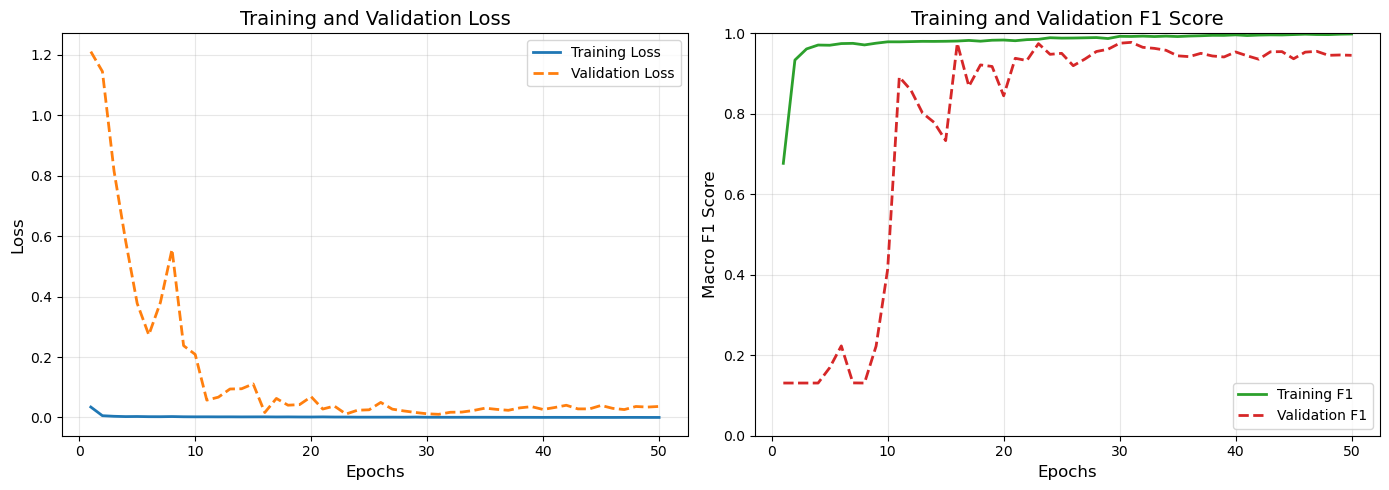


=== Evaluating on Test Data ===


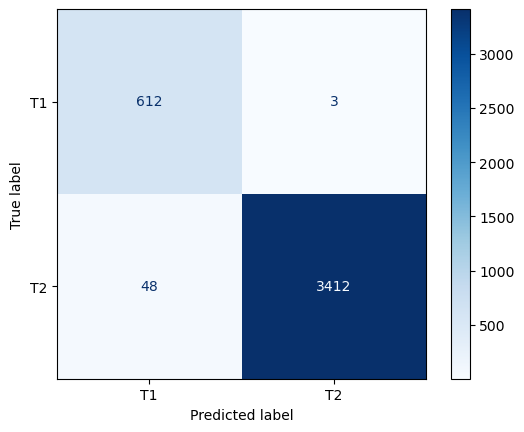

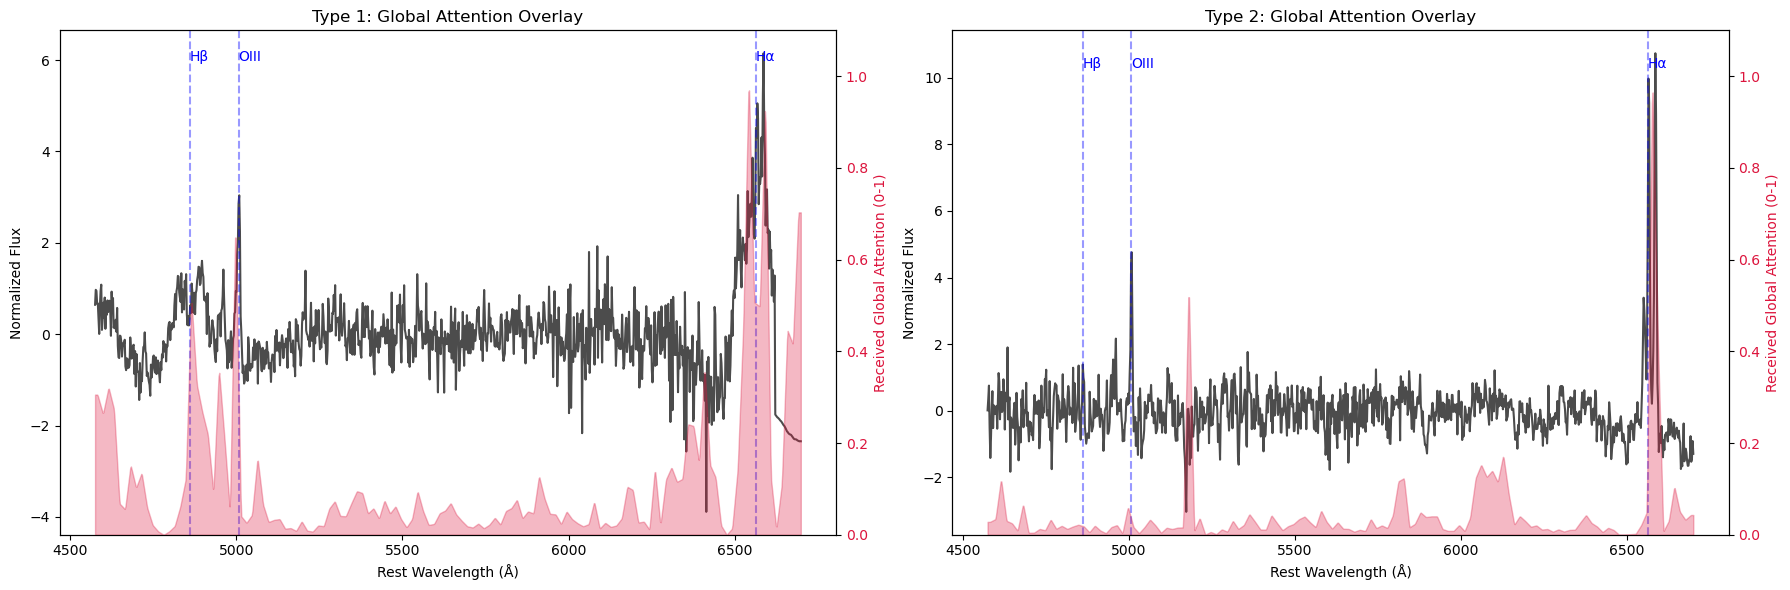

In [2]:
train_model()

In [ ]:
df = pd.read_parquet('../data/processed_agn_catalog.parquet')


In [ ]:
sum(df['z'].isna())

In [ ]:
z1 = df.loc[df['agn_type'] == 1, 'z']
z2 = df.loc[df['agn_type'] == 2, 'z']


plt.hist(z1,alpha = 0.8,density=True,label = 'type1')
plt.hist(z2,alpha = 0.8,density=True,label = 'type2')
plt.legend()
plt.show()

In [ ]:
# 1. Identify EXACTLY what is in X
all_cols = df.columns.tolist()
# Explicitly list EVERY non-flux column you've ever mentioned
forbidden_cols = ['filename', 'agn_type', 'z', 'snr', 'obj_id', 'index', 'Unnamed: 0']
flux_cols = [c for c in all_cols if c not in forbidden_cols]

X_test = df[flux_cols].values
print(f"DEBUG: X has {X_test.shape[1]} columns.")

# 2. THE ULTIMATE SANITY CHECK
if X_test.shape[1] != 4096:
    print(f"CRITICAL ERROR: X has {X_test.shape[1]} columns. You are leaking metadata!")

In [ ]:
df['agn_type']

In [ ]:
z1 = df.loc[df['agn_type'] == 1, 'z']
z2 = df.loc[df['agn_type'] == 2,'z']

In [ ]:
df_filtered = df[(df['z'] > 0.15) & (df['z'] < 0.22)]


df_filtered['agn_type'].value_counts()


In [ ]:
import pandas as pd
import numpy as np

# Load your 4096-column processed data
df = pd.read_parquet('../data/processed_agn_catalog.parquet')
meta_cols = ['filename', 'agn_type', 'z', 'snr', 'obj_id']
flux_cols = [c for c in df.columns if c not in meta_cols]
wavelengths = np.array(flux_cols).astype(float)

# Identify which pixels are NEVER zero across the whole dataset
# (We check for != 0.0 across all rows)
is_never_zero = (df[flux_cols] != 0.0).all(axis=0)

# The 'Safe Box' is the range where this mask is True
safe_wavelengths = wavelengths[is_never_zero]
blue_limit = safe_wavelengths.min()
red_limit = safe_wavelengths.max()

print(f"--- Safe Overlap Analysis ---")
print(f"Safe Blue Limit: {blue_limit:.1f} Å")
print(f"Safe Red Limit:  {red_limit:.1f} Å")
print(f"Total valid range: {red_limit - blue_limit:.1f} Å")

In [ ]:
meta_cols = ['filename', 'agn_type', 'z', 'snr', 'obj_id']
# Everything else is a wavelength (as a string)
flux_cols = [c for c in df.columns if c not in meta_cols]
wavelengths = np.array(flux_cols).astype(float)

# --- 3. Detect the "Zero Cliff" ---
# Convert to numpy matrix for speed
flux_matrix = df[flux_cols].values

# Find the index of the last non-zero value for every row
# This tells us where the real data ends and padding begins
def find_last(row):
    nonzero = np.where(row != 0.0)[0]
    return nonzero[-1] if len(nonzero) > 0 else 0

last_indices = np.apply_along_axis(find_last, 1, flux_matrix)

# Map indices back to actual wavelengths
df['padding_start_wave'] = wavelengths[last_indices]

# --- 4. Plot the Distribution ---
plt.figure(figsize=(10, 6))

# Filter by Type 1 and Type 2
t1 = df[df['agn_type'] == 1]['padding_start_wave']
t2 = df[df['agn_type'] == 2]['padding_start_wave']

plt.hist(t1, bins=50, alpha=0.5, label='Type 1', color='#3498db')
plt.hist(t2, bins=50, alpha=0.5, label='Type 2', color='#e67e22')

plt.axvline(t1.min(), color='red', linestyle='--', label=f'Safe Cutoff: {t1.min():.0f}Å')

plt.title('Distribution of Spectral End-Points (Where Zeros Begin)', fontsize=14)
plt.xlabel('Rest-Frame Wavelength (Å)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- 5. Print the Evidence ---
print("\n=== Padding Analysis ===")
print(f"Type 1 (Minority) usually ends at: {t1.mean():.1f} Å")
print(f"Type 2 (Majority) usually ends at: {t2.mean():.1f} Å")
print(f"\nTo stop the 'cheating', you should crop the grid to: {t1.min():.0f} Å")

In [ ]:
df['z'].describe()